# 📊 Time Series Forecasting Analysis

## Internship Task - 4  
### Data Science & Analytics  

**Name:** Sudhanshu Pathak  
**Objective:** To analyze time-based sales data and build a forecasting model to predict future trends.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 📌 Importing Libraries

We import essential Python libraries:
- **Pandas** for data manipulation  
- **NumPy** for numerical operations  
- **Matplotlib & Seaborn** for data visualization  

In [4]:
df = pd.read_csv("superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 📂 Loading Dataset

The dataset is loaded using Pandas.  
It contains retail sales data including order date, sales, category, and region.

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 📊 Dataset Overview

- The dataset contains sales transaction records.  
- Key columns include:
  - **Order Date** (time variable)
  - **Sales** (target variable)
  - Other features such as Category, Region, and Profit  

This dataset is suitable for time-series analysis.

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

## 🕒 Date Conversion

The 'Order Date' column is converted into datetime format.

Since the dataset uses **DD-MM-YYYY format**, the parameter `dayfirst=True` is used  
to correctly interpret the date values.

In [9]:
df = df.sort_values('Order Date')

## 🔄 Sorting Data

The dataset is sorted by 'Order Date' to maintain chronological order  
which is essential for time-series analysis.

In [10]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

## 🧹 Data Cleaning

- Checked for missing values in all columns  
- Checked for duplicate records  

No major data quality issues were found (or handled if present).

In [11]:
# Extract time-based features
df['Month'] = df['Order Date'].dt.month
df['Day_of_Week'] = df['Order Date'].dt.day_name()

## 🧠 Feature Engineering

New time-based features are created from the 'Order Date' column:

- **Month** → helps analyze monthly trends  
- **Day of Week** → helps identify weekly patterns  

These features are useful for understanding seasonality and behavior over time.

In [12]:
# Create monthly sales data
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

monthly_sales.head()

C:\Users\SUDHANSHU PATHAK\AppData\Local\Temp\ipykernel_29136\1118016142.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

## 📅 Monthly Sales Aggregation

The data is aggregated on a monthly level using the resampling method.

This helps in:
- Identifying long-term trends  
- Reducing noise from daily fluctuations  
- Making forecasting easier and more meaningful  

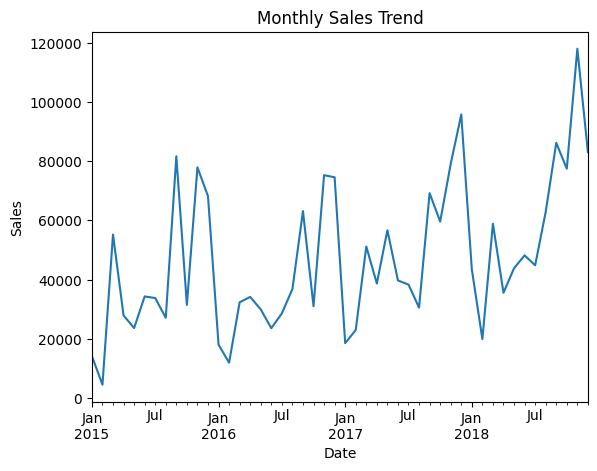

In [13]:
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 📈 Sales Trend Analysis

The line chart shows the trend of sales over time.

### Observations:
- Sales show an overall increasing trend  
- There are fluctuations indicating seasonal variations  
- Certain months show peaks, possibly due to high demand periods  

This indicates that sales are not constant and vary over time.

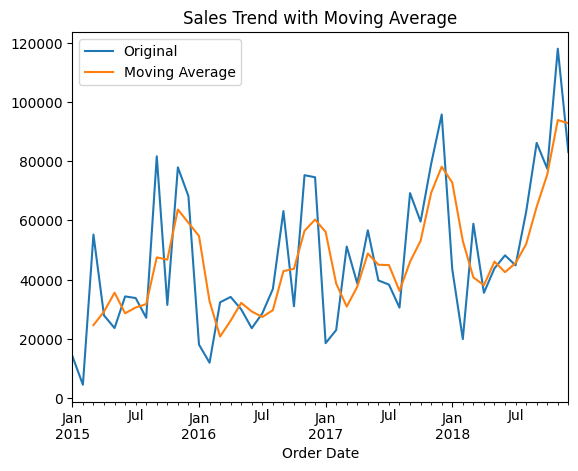

In [14]:
# Moving average
monthly_sales_ma = monthly_sales.rolling(window=3).mean()

plt.figure()
monthly_sales.plot(label='Original')
monthly_sales_ma.plot(label='Moving Average')
plt.legend()
plt.title("Sales Trend with Moving Average")
plt.show()

## 📊 Moving Average Analysis

A 3-month moving average is used to smooth the data.

### Insights:
- Reduces short-term fluctuations  
- Highlights the overall trend clearly  
- Shows steady growth pattern  

This helps in better understanding long-term behavior of sales.

In [15]:
# Reset index to convert date into column
monthly_sales = monthly_sales.reset_index()

# Create time index
monthly_sales['Time'] = np.arange(len(monthly_sales))

monthly_sales.head()

,Order Date,Sales,Time
0,2015-01-31,14205.707,0
1,2015-02-28,4519.892,1
2,2015-03-31,55205.797,2
3,2015-04-30,27906.855,3
4,2015-05-31,23644.303,4


## 🔢 Preparing Data for Forecasting

To apply a machine learning model, we convert time into a numerical format.

- A new column **Time** is created as a sequence (0,1,2,3...)
- This helps the model understand the progression of time

In [16]:
from sklearn.linear_model import LinearRegression

# Features and target
X = monthly_sales[['Time']]
y = monthly_sales['Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## 🤖 Forecasting Model

A **Linear Regression model** is used to predict future sales.

- It finds a linear relationship between time and sales  
- Simple yet effective for trend-based forecasting  

In [17]:
# Predict next 6 months
future_time = np.arange(len(monthly_sales), len(monthly_sales) + 6).reshape(-1, 1)

future_predictions = model.predict(future_time)

future_predictions

c:\Users\SUDHANSHU PATHAK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([68878.99833333, 69767.31052491, 70655.6227165 , 71543.93490808,
       72432.24709966, 73320.55929124])

## 🔮 Future Predictions

The model is used to forecast sales for the next 6 months.

These predictions help in understanding future demand trends.

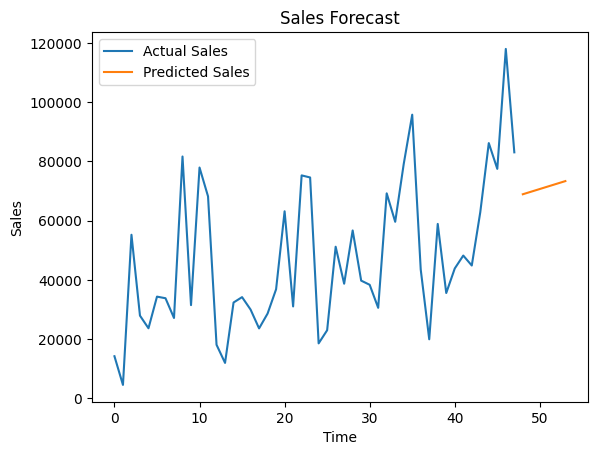

In [18]:
plt.figure()

# Actual data
plt.plot(monthly_sales['Time'], monthly_sales['Sales'], label='Actual Sales')

# Future predictions
plt.plot(future_time, future_predictions, label='Predicted Sales')

plt.legend()
plt.title("Sales Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.show()

## 📊 Sales Forecast Visualization

The graph shows both:
- Actual historical sales  
- Predicted future sales  

### Observation:
The forecast indicates a continuation of the existing trend.

## 💡 Key Insights

1. Sales show an overall increasing trend over time  
2. Seasonal fluctuations are observed in certain months  
3. Peak sales periods indicate high customer demand  
4. Moving average confirms a steady upward trend  
5. Forecast suggests continued growth in future months  
6. Demand is not uniform and varies across time  
7. Certain periods consistently perform better than others  

## 📌 Business Recommendations

1. Increase inventory before peak sales months  
2. Plan marketing campaigns during low-sales periods  
3. Focus on high-performing time periods for promotions  
4. Optimize supply chain based on predicted demand  
5. Allocate resources efficiently during high-demand periods  
6. Monitor trends regularly for better decision-making  